# Plastic-Field Shape Matching — A Differentiable Inverse-Design Tutorial


## Outline

1. Kinematics — the plastic field and $\mathbf F=\mathbf F_e\mathbf F_p$
2. Forward problem — static equilibrium (the inner solve)
3. Inverse problem — the shape-matching objective (the outer solve)
4. The adjoint method — differentiating through equilibrium
5. Setup — imports and output directory
6. Build the simulation mesh and the plastic deformation model
7. Extract the surface, sculpt a target, set boundary conditions
8. One forward + one gradient — a sanity check
9. The outer optimization loop (Adam)
10. Inspect the learned plastic field
11. A stronger prior — a *constant* plastic field
12. Same loop, six global DOFs
13. Read the single learned tensor & compare
14. Recap, pitfalls, and extensions


## 1. Kinematics — the plastic field and $\mathbf F=\mathbf F_e\mathbf F_p$

Deformation of a solid is described locally by the **deformation gradient**
$\mathbf F=\partial\mathbf x/\partial\mathbf X\in\mathbb R^{3\times3}$, mapping a
rest neighborhood to its deformed counterpart. Elasto-plasticity splits this
map **multiplicatively** into a plastic part and an elastic part:

$$\mathbf F=\mathbf F_e\,\mathbf F_p .$$

Read right to left: $\mathbf F_p$ first carries material to a *stress-free
intermediate (plastic) state*, then $\mathbf F_e$ elastically deforms it to the
observed configuration. Crucially, **only the elastic part stores energy**:

$$\mathbf F_e=\mathbf F\,\mathbf F_p^{-1}.$$

### The plastic field in pypgo (`VolumetricPlasticity(dofs=6)`)

We attach one plastic tensor **per element**. With `dofs=6` it is a *symmetric*
$3\times3$ tensor $\mathbf S$ parameterized by 6 numbers (channels
`Sxx, Sxy, Sxz, Syy, Syz, Szz`):

$$
\mathbf S=\begin{bmatrix} S_{xx}&S_{xy}&S_{xz}\\ S_{xy}&S_{yy}&S_{yz}\\
S_{xz}&S_{yz}&S_{zz}\end{bmatrix},
\qquad
\mathbf F_p=\mathbf R^{\!\top}\,\mathbf S\,\mathbf R .
$$

$\mathbf R$ is a per-element fiber frame; here it is the identity, so
$\mathbf F_p=\mathbf S$. The **rest plastic state is $\mathbf S=\mathbf I$**, i.e.
channels $(1,0,0,1,0,1)$ — no plastic distortion. (This is why the default
seed below is $(1,0,0,1,0,1)$ and *not* zeros; the *plastic strain* is
$\mathbf S-\mathbf I$, which vanishes at rest.) Stacking all elements gives the
design vector $\mathbf a\in\mathbb R^{6 n_{\text{ele}}}$.

### Total energy

With a per-element rest volume $V_e$ and the St.\ Venant–Kirchhoff (StVK)
elastic density $\psi$, the body's stored energy is

$$
E(\mathbf u,\mathbf a)=\sum_{e} V_e\,\psi\!\big(\mathbf F_e(\mathbf u,\mathbf a_e)\big),
\qquad
\psi(\mathbf F_e)=\mu\,\lVert \mathbf E\rVert_F^2+\tfrac{\lambda}{2}\,\mathrm{tr}(\mathbf E)^2,
$$

where $\mathbf E=\tfrac12(\mathbf F_e^{\!\top}\mathbf F_e-\mathbf I)$ is the Green strain and
$(\mu,\lambda)$ are the Lamé parameters from the material's $(E,\nu)$. The
displacement $\mathbf u$ (vertex positions minus rest) enters through
$\mathbf F=\mathbf F(\mathbf u)$; the design $\mathbf a$ enters through $\mathbf F_p$.


## 2. Forward problem — static equilibrium (the inner solve)

Clamp the base with Dirichlet conditions $\mathbf u_b=\bar{\mathbf u}$ (here
$\bar{\mathbf u}=\mathbf 0$ on the bottom face). For a **fixed** plastic field
$\mathbf a$, the block relaxes to the displacement that minimizes its energy:

$$
\mathbf u^\star(\mathbf a)=\arg\min_{\mathbf u:\,\mathbf u_b=\bar{\mathbf u}}\;E(\mathbf u,\mathbf a).
$$

Stationarity says the internal forces on the **free** DOFs vanish:

$$
\mathbf g_f(\mathbf u^\star,\mathbf a):=\frac{\partial E}{\partial \mathbf u_f}\Big|_{\mathbf u^\star}=\mathbf 0 .
$$

A Newton iteration solves this nonlinear system — this is precisely what
`StaticEquilibriumLayer.forward` does (via `pypgo.solver.NewtonOptimizer`),
warm-starting from the previous outer step. The quantities we will reuse for
the gradient are the **tangent stiffness** (Hessian) and the **plastic
Jacobian**:

$$
\mathbf H=\frac{\partial^2 E}{\partial \mathbf u^2}\in\mathbb R^{n_u\times n_u},
\qquad
\mathbf J=\frac{\partial^2 E}{\partial \mathbf u\,\partial \mathbf a}
=\frac{\partial \mathbf g}{\partial \mathbf a}\in\mathbb R^{n_u\times n_a}.
$$

These are exposed as `energy.hessian(u)` and `energy.plastic_jacobian(u)`.
Finally we *observe* only the surface vertices,
$\mathbf x_{\text{surf}}(\mathbf a)=\mathbf X_{\text{surf}}+\mathbf P\,\mathbf u^\star(\mathbf a)$,
where $\mathbf P$ selects the surface DOFs.


## 3. Inverse problem — the shape-matching objective (the outer solve)

Let $\hat{\mathbf x}$ be the target surface positions. We minimize a least-squares
shape error plus a Tikhonov regularizer toward the rest plastic state
$\mathbf a_0$ (the identity tensors):

$$
L(\mathbf a)=\underbrace{\tfrac12\big\lVert \mathbf x_{\text{surf}}(\mathbf a)-\hat{\mathbf x}\big\rVert^2}_{\text{shape term}}
\;+\;\underbrace{\tfrac{\mu_{\text{reg}}}{2}\big\lVert \mathbf a-\mathbf a_0\big\rVert^2}_{\text{regularizer}} .
$$

The regularizer keeps the plastic program *minimal* (prefer the smallest
plastic strain that explains the shape) and makes the otherwise
under-determined inverse problem well-posed. The **outer** problem is

$$
\mathbf a^\star=\arg\min_{\mathbf a} L(\mathbf a),
$$

solved here with Adam. The coupling is *bilevel*: every outer evaluation of
$L$ runs a full inner equilibrium solve $\mathbf u^\star(\mathbf a)$.


## 4. The adjoint method — differentiating through equilibrium

To run Adam we need $\nabla_{\mathbf a}L$. The shape term depends on $\mathbf a$
**only through** $\mathbf u^\star(\mathbf a)$, which is defined *implicitly* by
$\mathbf g_f(\mathbf u^\star,\mathbf a)=\mathbf 0$ — there is no closed form. The
**implicit function theorem** rescues us: differentiate the equilibrium
condition with respect to $\mathbf a$,

$$
\mathbf H_{ff}\,\frac{d\mathbf u_f^\star}{d\mathbf a}+\mathbf J_f=\mathbf 0
\quad\Longrightarrow\quad
\frac{d\mathbf u_f^\star}{d\mathbf a}=-\,\mathbf H_{ff}^{-1}\mathbf J_f,
$$

where $\mathbf H_{ff}$ is the free–free block of the Hessian and $\mathbf J_f$ the
free rows of the plastic Jacobian. Now apply the chain rule to the shape
term. Let $\mathbf r=\mathbf x_{\text{surf}}-\hat{\mathbf x}$ be the residual; then
$\partial L_{\text{shape}}/\partial \mathbf x_{\text{surf}}=\mathbf r$ and, scattered
back to full DOFs, $\mathbf b=\mathbf P^{\!\top}\mathbf r=\partial L_{\text{shape}}/\partial\mathbf u$.
Therefore

$$
\frac{dL_{\text{shape}}}{d\mathbf a}
=\mathbf b_f^{\!\top}\frac{d\mathbf u_f^\star}{d\mathbf a}
=-\,\mathbf b_f^{\!\top}\mathbf H_{ff}^{-1}\mathbf J_f
=-\,\boldsymbol\lambda_f^{\!\top}\mathbf J_f,
\qquad
\boxed{\;\mathbf H_{ff}\,\boldsymbol\lambda_f=\mathbf b_f\;}
$$

The **adjoint trick**: instead of forming the dense sensitivity
$d\mathbf u^\star/d\mathbf a$ (one solve *per design variable*), solve **one**
linear system for the adjoint $\boldsymbol\lambda_f$, then contract with
$\mathbf J$. Adding the (explicit) regularizer gradient,

$$
\nabla_{\mathbf a}L=-\,\mathbf J^{\!\top}\boldsymbol\lambda\;+\;\mu_{\text{reg}}(\mathbf a-\mathbf a_0).
$$

### How this maps to `StaticEquilibriumLayer`

| Math | Code (in `pypgo/torch.py`) |
|---|---|
| solve $\mathbf u^\star(\mathbf a)$ | `forward`: `inner_optimizer.solve(problem, warm_start)` |
| upstream $\mathbf r=\partial L/\partial\mathbf x_{\text{surf}}$ | `backward`'s `grad_surface` (from autograd) |
| scatter $\mathbf b=\mathbf P^{\!\top}\mathbf r$ | `np.add.at(grad_u, surface_vertex_ids, grad_surface)` |
| adjoint $\mathbf H_{ff}\boldsymbol\lambda_f=\mathbf b_f$ | `np.linalg.solve(H[free,free], grad_u[free])` |
| $-\mathbf J^{\!\top}\boldsymbol\lambda$ | `-(plastic_jacobian.T @ adjoint)` |
| $\mu_{\text{reg}}(\mathbf a-\mathbf a_0)$ | added by PyTorch autograd (the term is explicit) |

The shape term's gradient is produced by the custom `autograd.Function`; the
regularizer's gradient is produced by ordinary autograd because
$(\mathbf a-\mathbf a_0)$ appears explicitly in the Python loss. PyTorch sums them.

> **Why `enforce_spd=False`?** The adjoint needs the *true* Hessian
> $\partial^2E/\partial\mathbf u^2$. SPD-projecting it (a common Newton
> stabilizer) would bias the sensitivity. We also pass
> `enable_material_max_step=False` so the inner solve uses the plain analytic
> tangent. For this small, well-conditioned block Newton converges fine
> without those guards.


## 5. Setup — imports and output directory

`pypgo.torch` is pypgo's PyTorch bridge (distinct from the `torch` package).
The layer currently runs on **CPU `float64`** tensors only.


In [31]:
from pathlib import Path

import numpy as np
import pypgo as pgo
import pypgo.fem as pf
import pypgo.solver as ps
import torch

PACKAGE_ROOT = Path(pgo.__file__).resolve().parent
OUTPUT_DIR = PACKAGE_ROOT / "examples" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

np.set_printoptions(precision=4, suppress=True)
torch.set_default_dtype(torch.float64)


## 6. Build the simulation mesh and the plastic deformation model

We procedurally build a dense $4\times4\times4$ unit cube of trilinear hex
elements (125 vertices, 64 elements). `vertex_id(i, j, k)` is the standard
lexicographic index; `cube_elements` lists the 8 corners of each cell in
pypgo's hex ordering.

The deformation model wires together four choices:

- `elastic=pf.StVK()` — the elastic density $\psi$ above.
- `plastic=pf.VolumetricPlasticity(dofs=6)` — the symmetric plastic tensor
  $\mathbf S$ (6 channels) per element.
- `*_field=pf.ElementwiseField()` — each element owns its own parameters
  (vs. a single mesh-wide `ConstantField`).
- `formulation=pf.LinearCubic()` — **required** for hex meshes.

`state.plastic_field.values` comes seeded with the **rest** plastic state
$\mathbf S=\mathbf I$, i.e. rows $(1,0,0,1,0,1)$ — we keep a copy as our
reference `initial_plastic` so that later `optimized − initial` is exactly
the *learned plastic strain* $\mathbf S^\star-\mathbf I$.


In [32]:
nx = ny = nz = 4

def vertex_id(i, j, k):
    return i * (ny + 1) * (nz + 1) + j * (nz + 1) + k

cube_vertices = np.array(
    [
        [i / nx, j / ny, k / nz]
        for i in range(nx + 1)
        for j in range(ny + 1)
        for k in range(nz + 1)
    ],
    dtype=np.float64,
)
cube_elements = np.array(
    [
        [
            vertex_id(i, j, k),
            vertex_id(i + 1, j, k),
            vertex_id(i + 1, j + 1, k),
            vertex_id(i, j + 1, k),
            vertex_id(i, j, k + 1),
            vertex_id(i + 1, j, k + 1),
            vertex_id(i + 1, j + 1, k + 1),
            vertex_id(i, j + 1, k + 1),
        ]
        for i in range(nx)
        for j in range(ny)
        for k in range(nz)
    ],
    dtype=np.int64,
)

cubic = pgo.mesh.CubicMeshData(cube_vertices, cube_elements)
volume = pgo.mesh.veg.VolumeMesh.create_from_single_material(
    cubic, pgo.mesh.veg.ENuMaterial(E=1e6, nu=0.45)
)
sim = pgo.sim.SimulationMesh.create_volumetric(volume)
print("hex grid:", nx, "x", ny, "x", nz,
      "->", cube_vertices.shape[0], "vertices,", cube_elements.shape[0], "elements")
pgo.vis.plot_volume_surface(cubic, titles=["rest cubic volume"], show_edges=True)


hex grid: 4 x 4 x 4 -> 125 vertices, 64 elements


Widget(value='<iframe src="http://localhost:49856/index.html?ui=P_0x34311c200_15&reconnect=auto" class="pyvist…

In [33]:
state = pf.deformation_model_state(
    sim,
    elastic=pf.StVK(),
    elastic_field=pf.ElementwiseField(),
    plastic=pf.VolumetricPlasticity(dofs=6),
    plastic_field=pf.ElementwiseField(),
)
# enforce_spd=False keeps the TRUE Hessian for an unbiased adjoint;
# enable_material_max_step=False keeps the plain analytic tangent.
energy = pf.deformation_energy(
    state,
    formulation=pf.LinearCubic(),
    options=pf.DeformationOptions(enforce_spd=False, enable_material_max_step=False),
)

# Rest plastic state S = I per element, channels (Sxx,Sxy,Sxz,Syy,Syz,Szz).
initial_plastic = state.plastic_field.values.copy()
initial_plastic_norm = np.linalg.norm(initial_plastic, axis=1)

print("plastic field shape:", state.plastic_field.values.shape,
      "channels:", state.plastic_field.num_channels)
print("rest plastic row[0] (should be identity):", initial_plastic[0])
print("deformation dofs:", energy.num_dofs, "| plastic dofs:", energy.num_plastic_dofs)


[2026-06-04 17:14:37.964] [info] [deformationModelFactory.cpp:61] Building deformation energy with formulation: hex_trilinear and deformation model state
[2026-06-04 17:14:37.965] [info] [deformationModelManager.cpp:273] Initializing element models (manager path)...
[2026-06-04 17:14:37.966] [info] [deformationModelAssembler.cpp:95] Assembler parameter:0,6
plastic field shape: (64, 6) channels: 6
rest plastic row[0] (should be identity): [1. 0. 0. 1. 0. 1.]
deformation dofs: 375 | plastic dofs: 384


## 7. Extract the surface, sculpt a target, set boundary conditions

We optimize against the **observed surface**, so first we triangulate the
six outer faces of the cube into a `TriMeshData`. `surface_vertex_ids` maps
each surface vertex back to its global volumetric index — the selection
$\mathbf P$ from the theory — and `surface_lut` remaps global ids to local
surface ids for the triangle table.


In [34]:
boundary_mask = np.any(
    np.isclose(cube_vertices, 0.0) | np.isclose(cube_vertices, 1.0),
    axis=1,
)
surface_vertex_ids = np.flatnonzero(boundary_mask).astype(np.int64)
surface_lut = {int(global_id): local_id for local_id, global_id in enumerate(surface_vertex_ids)}
surface_triangles = []

def add_surface_quad(a, b, c, d):
    surface_triangles.append([surface_lut[int(a)], surface_lut[int(b)], surface_lut[int(c)]])
    surface_triangles.append([surface_lut[int(a)], surface_lut[int(c)], surface_lut[int(d)]])

# z = 0 / z = nz faces
for i in range(nx):
    for j in range(ny):
        add_surface_quad(vertex_id(i, j, 0), vertex_id(i + 1, j, 0), vertex_id(i + 1, j + 1, 0), vertex_id(i, j + 1, 0))
        add_surface_quad(vertex_id(i, j, nz), vertex_id(i, j + 1, nz), vertex_id(i + 1, j + 1, nz), vertex_id(i + 1, j, nz))
# y = 0 / y = ny faces
for i in range(nx):
    for k in range(nz):
        add_surface_quad(vertex_id(i, 0, k), vertex_id(i, 0, k + 1), vertex_id(i + 1, 0, k + 1), vertex_id(i + 1, 0, k))
        add_surface_quad(vertex_id(i, ny, k), vertex_id(i + 1, ny, k), vertex_id(i + 1, ny, k + 1), vertex_id(i, ny, k + 1))
# x = 0 / x = nx faces
for j in range(ny):
    for k in range(nz):
        add_surface_quad(vertex_id(0, j, k), vertex_id(0, j + 1, k), vertex_id(0, j + 1, k + 1), vertex_id(0, j, k + 1))
        add_surface_quad(vertex_id(nx, j, k), vertex_id(nx, j, k + 1), vertex_id(nx, j + 1, k + 1), vertex_id(nx, j + 1, k))

surface = pgo.mesh.TriMeshData(
    cube_vertices[surface_vertex_ids],
    np.asarray(surface_triangles, dtype=np.int64),
)
print("surface vertices:", surface.num_vertices, "| surface triangles:", surface.num_elements)


surface vertices: 98 | surface triangles: 192


### A height-dependent shear as the target

The target $\hat{\mathbf x}$ is a *known* deformation of the rest surface so the
problem is well-posed and visual: shear that grows linearly with height $y$,

$$\hat x \mathrel{+}= 0.35\,y,\qquad \hat z \mathrel{+}= 0.15\,y,$$

a lateral lean plus a slight twist out of plane. The block's base stays put;
the top leans the most.


In [35]:
shear_strength = 0.35
depth_shear = 0.15
target_vertices = surface.vertices.copy()
target_vertices[:, 0] += shear_strength * surface.vertices[:, 1]
target_vertices[:, 2] += depth_shear * surface.vertices[:, 1]
target_surface = pgo.mesh.TriMeshData(target_vertices, surface.elements)

pgo.vis.plot_surface(
    [surface, target_surface],
    titles=["rest cubic surface", "sheared cubic target"],
    colors=["lightgray", "palegreen"],
    show_edges=True,
    window_size=(900, 420),
)


Widget(value='<iframe src="http://localhost:49856/index.html?ui=P_0x33d5cbc50_16&reconnect=auto" class="pyvist…

### Boundary conditions and the differentiable equilibrium layer

We clamp the bottom face ($y=0$): those DOFs are *fixed* and removed from
the free set used in the adjoint solve. We then assemble the
`StaticEquilibriumLayer`, which packages the inner Newton solve plus its
adjoint backward pass behind a single PyTorch-callable module.

`a0` is the flat rest plastic vector $\mathbf a_0$ — both the **Adam start**
and the **regularization anchor**. `l2_weight` is $\mu_{\text{reg}}$.


In [36]:
fixed_vertices = np.flatnonzero(np.isclose(cube_vertices[:, 1], 0.0)).astype(np.int64)
fixed_dofs = (3 * fixed_vertices[:, None] + np.arange(3, dtype=np.int64)).ravel()
fixed_values = np.zeros(fixed_dofs.size, dtype=np.float64)
free_dofs = np.setdiff1d(np.arange(energy.num_dofs, dtype=np.int64), fixed_dofs)

inner_optimizer = ps.NewtonOptimizer(max_iterations=10, damping=False)
l2_weight = 1e-4  # mu_reg
a0 = state.plastic_field.values.ravel().copy()
a0_torch = torch.as_tensor(a0, dtype=torch.float64)
target_vertices_torch = torch.as_tensor(target_vertices, dtype=torch.float64)

equilibrium_layer = pgo.torch.StaticEquilibriumLayer(
    state=state,
    energy=energy,
    fixed_dofs=fixed_dofs,
    fixed_values=fixed_values,
    surface_vertices=surface.vertices,
    surface_vertex_ids=surface_vertex_ids,
    inner_optimizer=inner_optimizer,
)
print("fixed (bottom y=0) vertices:", fixed_vertices.size,
      "| free dofs:", free_dofs.size, "of", energy.num_dofs)


fixed (bottom y=0) vertices: 25 | free dofs: 300 of 375


## 8. One forward + one gradient — a sanity check

Before the loop, evaluate everything **once** at $\mathbf a=\mathbf a_0$:

1. `equilibrium_layer(plastic_param)` runs the inner solve and returns the
   observed surface $\mathbf x_{\text{surf}}(\mathbf a_0)$.
2. We form the loss $L(\mathbf a_0)$ and call `.backward()` — this exercises the
   full adjoint path and populates `plastic_param.grad=\nabla_{\mathbf a}L`.

A nonzero, finite gradient norm and a visible gap between the *initial
equilibrium* (blue) and the *target* (green) tell us the wiring is correct
and there is something to optimize. The helper below summarizes the residual
$\mathbf r$ as a few interpretable error statistics.


In [37]:
def vertex_error_stats(residual):
    vertex_errors = np.linalg.norm(residual, axis=1)
    global_error = float(np.linalg.norm(residual.ravel()))
    return {
        "global_error": global_error,
        "per_vertex_rms": global_error / np.sqrt(residual.shape[0]),
        "mean_vertex_error": float(vertex_errors.mean()),
        "max_vertex_error": float(vertex_errors.max()),
    }

def print_error_stats(label, stats):
    print(
        f"{label}: global={stats['global_error']:.6f}  "
        f"per-vertex RMS={stats['per_vertex_rms']:.6f}  "
        f"mean={stats['mean_vertex_error']:.6f}  "
        f"max={stats['max_vertex_error']:.6f}"
    )


In [38]:
plastic_param = torch.tensor(a0.copy(), dtype=torch.float64, requires_grad=True)
initial_vertices = equilibrium_layer(plastic_param)
initial_residual = initial_vertices - target_vertices_torch
initial_shape_loss = 0.5 * torch.sum(initial_residual ** 2)
initial_regularization = 0.5 * l2_weight * torch.sum((plastic_param - a0_torch) ** 2)
initial_loss = initial_shape_loss + initial_regularization
initial_loss.backward()

print("initial objective L(a0):", float(initial_loss.detach()))
print_error_stats("initial shape error", vertex_error_stats(initial_residual.detach().numpy()))
print("gradient norm ||dL/da||:", float(torch.linalg.norm(plastic_param.grad)))

initial_surface = pgo.mesh.TriMeshData(initial_vertices.detach().numpy(), surface.elements)
pgo.vis.plot_surface(
    [surface, target_surface, initial_surface],
    titles=["rest", "target", "initial equilibrium (a = a0)"],
    colors=["lightgray", "palegreen", "lightskyblue"],
    show_edges=True,
    window_size=(1200, 420),
)


[2026-06-04 17:14:38.128] [info] [NewtonSolver.cpp:383] Newton solve time: 0.004121
initial objective L(a0): 2.8274999999999997
initial shape error: global=2.378024  per-vertex RMS=0.240217  mean=0.190394  max=0.380789
gradient norm ||dL/da||: 5.391854125315113


Widget(value='<iframe src="http://localhost:49856/index.html?ui=P_0x33fdb7170_17&reconnect=auto" class="pyvist…

## 9. The outer optimization loop (Adam)

Now iterate $\mathbf a\leftarrow\text{Adam}(\mathbf a,\nabla_{\mathbf a}L)$. Each step:

1. `equilibrium_layer(plastic_param)` → inner solve $\mathbf u^\star(\mathbf a)$
   (warm-started from the previous step, so later solves are cheap).
2. Build $L=\tfrac12\lVert\mathbf r\rVert^2+\tfrac{\mu_{\text{reg}}}{2}\lVert\mathbf a-\mathbf a_0\rVert^2$.
3. `loss.backward()` → adjoint gradient (Section 4).
4. `optimizer.step()` → Adam update.

Because the inner solve has a finite tolerance, the outer objective can wiggle
slightly; we therefore **track the best iterate** `best_plastic` rather than
trusting the last one. After the loop we `reset_warm_start()` and re-solve from
zero for a clean, reproducible final shape.


In [39]:
num_outer_steps = 60
learning_rate = 0.01
plastic_param = torch.tensor(a0.copy(), dtype=torch.float64, requires_grad=True)
outer_optimizer = torch.optim.Adam([plastic_param], lr=learning_rate)
history = []
best_value = np.inf
best_plastic = a0.copy()

for iteration in range(num_outer_steps):
    outer_optimizer.zero_grad()
    solved_vertices = equilibrium_layer(plastic_param)
    residual = solved_vertices - target_vertices_torch
    shape_loss = 0.5 * torch.sum(residual ** 2)
    regularization = 0.5 * l2_weight * torch.sum((plastic_param - a0_torch) ** 2)
    loss = shape_loss + regularization
    loss.backward()

    value = float(loss.detach())
    stats = vertex_error_stats(residual.detach().numpy())
    if value < best_value:
        best_value = value
        best_plastic = plastic_param.detach().numpy().copy()
    outer_optimizer.step()
    history.append((value, stats["global_error"], stats["mean_vertex_error"]))
    if iteration < 5 or (iteration + 1) % 10 == 0:
        print(
            f"step {iteration + 1:3d}  objective={value:.6f}  "
            f"global_error={stats['global_error']:.6f}  "
            f"mean_vertex={stats['mean_vertex_error']:.6f}  "
            f"grad={float(torch.linalg.norm(plastic_param.grad)):.6f}"
        )

print(f"\nbest objective over {num_outer_steps} steps: {best_value:.6f}")


[2026-06-04 17:14:38.361] [info] [NewtonSolver.cpp:383] Newton solve time: 0.017569
step   1  objective=2.827500  global_error=2.378024  mean_vertex=0.190394  grad=5.391854
[2026-06-04 17:14:38.421] [info] [NewtonSolver.cpp:383] Newton solve time: 0.0307
step   2  objective=2.152382  global_error=2.074791  mean_vertex=0.166423  grad=4.638305
[2026-06-04 17:14:38.467] [info] [NewtonSolver.cpp:383] Newton solve time: 0.021469
step   3  objective=1.589338  global_error=1.782880  mean_vertex=0.143421  grad=3.904227
[2026-06-04 17:14:38.507] [info] [NewtonSolver.cpp:383] Newton solve time: 0.017147
step   4  objective=1.138020  global_error=1.508644  mean_vertex=0.121860  grad=3.189338
[2026-06-04 17:14:38.548] [info] [NewtonSolver.cpp:383] Newton solve time: 0.017218
step   5  objective=0.796047  global_error=1.261760  mean_vertex=0.102425  grad=2.500298
[2026-06-04 17:14:38.589] [info] [NewtonSolver.cpp:383] Newton solve time: 0.017301
[2026-06-04 17:14:38.632] [info] [NewtonSolver.cpp:38

### Evaluate the best design and save the result

We re-solve at `best_plastic` from a fresh warm start, recompute the shape /
regularization split, and persist everything (the learned plastic field, the
per-element norms, and the matched geometry) to an `.npz` for downstream use.


In [40]:
optimized_plastic_tensor = torch.as_tensor(best_plastic, dtype=torch.float64)
equilibrium_layer.reset_warm_start()
optimized_vertices = equilibrium_layer(optimized_plastic_tensor).detach().numpy().copy()
final_residual = optimized_vertices - target_vertices
final_shape_value = 0.5 * float(np.dot(final_residual.ravel(), final_residual.ravel()))
final_regularization = 0.5 * l2_weight * float(np.dot(best_plastic - a0, best_plastic - a0))
final_value = final_shape_value + final_regularization

print("final objective:", final_value,
      "(shape:", final_shape_value, "+ reg:", final_regularization, ")")
print_error_stats("final shape error", vertex_error_stats(final_residual))

optimized_plastic = best_plastic.reshape(state.plastic_field.values.shape)
plastic_delta = optimized_plastic - initial_plastic  # learned plastic strain S* - I
optimized_plastic_norm = np.linalg.norm(optimized_plastic, axis=1)
plastic_delta_norm = np.linalg.norm(plastic_delta, axis=1)

print("optimized plastic norm min/max:", optimized_plastic_norm.min(), optimized_plastic_norm.max())
print("plastic strain |S*-I| min/max:", plastic_delta_norm.min(), plastic_delta_norm.max())
print("optimized plastic sample rows (Sxx,Sxy,Sxz,Syy,Syz,Szz):")
print(optimized_plastic[: min(8, optimized_plastic.shape[0])])

weight_path = OUTPUT_DIR / "plastic_shape_match_weights.npz"
np.savez(
    weight_path,
    initial_plastic=initial_plastic,
    optimized_plastic=optimized_plastic,
    plastic_delta=plastic_delta,
    initial_plastic_norm=initial_plastic_norm,
    optimized_plastic_norm=optimized_plastic_norm,
    plastic_delta_norm=plastic_delta_norm,
    cube_vertices=cube_vertices,
    cube_elements=cube_elements,
    surface_vertex_ids=surface_vertex_ids,
    target_vertices=target_vertices,
    optimized_vertices=optimized_vertices,
)
print("saved plastic weights ->", weight_path)

optimized_surface = pgo.mesh.TriMeshData(optimized_vertices, surface.elements)
pgo.vis.plot_surface(
    [target_surface, optimized_surface],
    titles=["target", "optimized equilibrium"],
    colors=["palegreen", "salmon"],
    show_edges=True,
    window_size=(900, 420),
)


[2026-06-04 17:14:40.791] [info] [NewtonSolver.cpp:383] Newton solve time: 0.041174
final objective: 0.00814439585110142 (shape: 0.007980169788412102 + reg: 0.00016422606268931978 )
final shape error: global=0.126334  per-vertex RMS=0.012762  mean=0.010066  max=0.029322
optimized plastic norm min/max: 1.6726166519903778 1.976826999259321
plastic strain |S*-I| min/max: 0.11493406556561224 0.32124160556760384
optimized plastic sample rows (Sxx,Sxy,Sxz,Syy,Syz,Szz):
[[ 1.0634  0.1368 -0.1859  1.0497  0.1031  1.0767]
 [ 1.0654  0.1503 -0.2152  1.0468  0.0918  1.0842]
 [ 1.0532  0.1704 -0.1523  1.0432  0.1346  1.0734]
 [ 1.064   0.1652  0.2159  1.055  -0.0405  1.0856]
 [ 0.967   0.1405  0.0126  1.0313  0.0791  1.0081]
 [ 0.9345  0.1621 -0.0343  1.0235  0.1155  1.0254]
 [ 0.9362  0.1585  0.019   1.0228  0.0374  1.0636]
 [ 0.9488  0.1133 -0.0064  1.0396  0.031   1.0071]]
saved plastic weights -> /Users/jinceyang/Desktop/codebase/libpgo/pypgo/examples/outputs/plastic_shape_match_weights.npz


Widget(value='<iframe src="http://localhost:49856/index.html?ui=P_0x33fd78860_18&reconnect=auto" class="pyvist…

### Convergence history

We plot the outer objective and the global shape error against the Adam
iteration. The objective $L(\mathbf a)$ is on a **log** axis (it drops by
roughly two orders of magnitude); the global error
$\lVert\mathbf r\rVert$ is on the twin axis, and the dashed line marks the
best iterate we kept.


objective:    start=2.8275  ->  end=0.0081  (best=0.0081 @ step 60)
global error: start=2.3780  ->  end=0.1263


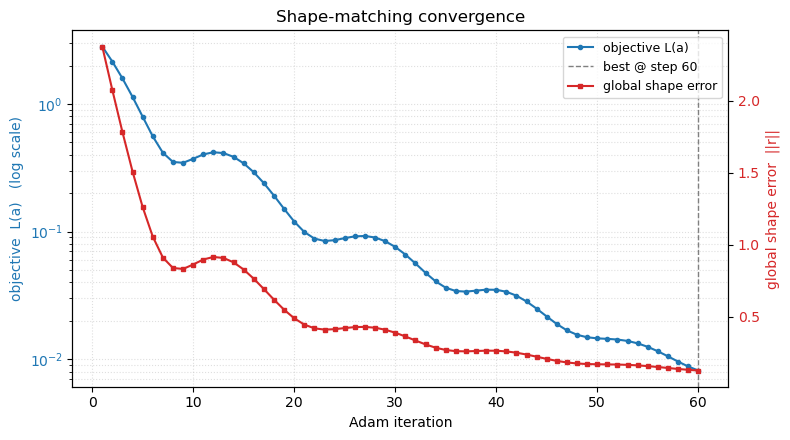

In [41]:
import matplotlib.pyplot as plt

objective_hist = np.array([h[0] for h in history])
global_hist = np.array([h[1] for h in history])
steps = np.arange(1, len(history) + 1)
best_step = int(np.argmin(objective_hist)) + 1
print(f"objective:    start={objective_hist[0]:.4f}  ->  end={objective_hist[-1]:.4f}  "
      f"(best={best_value:.4f} @ step {best_step})")
print(f"global error: start={global_hist[0]:.4f}  ->  end={global_hist[-1]:.4f}")

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.semilogy(steps, objective_hist, color="tab:blue", marker="o", ms=3, lw=1.5,
             label="objective L(a)")
ax1.axvline(best_step, color="gray", ls="--", lw=1.0, label=f"best @ step {best_step}")
ax1.set_xlabel("Adam iteration")
ax1.set_ylabel("objective  L(a)   (log scale)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, which="both", ls=":", alpha=0.4)

ax2 = ax1.twinx()
ax2.plot(steps, global_hist, color="tab:red", marker="s", ms=3, lw=1.5,
         label="global shape error")
ax2.set_ylabel("global shape error  ||r||", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=9)
ax1.set_title("Shape-matching convergence")
fig.tight_layout()
plt.show()


## 10. Inspect the learned plastic field

The optimizer distributed a **plastic strain** $\mathbf S-\mathbf I$ across the
elements so that, once relaxed, the surface leans into the target. Three
per-element scalars make this concrete:

- $\lVert \mathbf a_0\rVert$ — rest magnitude, uniform $\lVert\mathbf I\rVert_6=\sqrt3$.
- $\lVert \mathbf a^\star\rVert$ — optimized magnitude.
- $\lVert \mathbf a^\star-\mathbf a_0\rVert$ — the learned plastic strain, the
  physically meaningful "how much each element was reprogrammed".

Expect the largest strain where the shear gradient does the most work
(away from the clamped base).


In [42]:
print("plastic strain |S*-I|  mean:", plastic_delta_norm.mean(),
      " max:", plastic_delta_norm.max())

pgo.vis.plot_volume_surface(
    [cubic, cubic, cubic],
    titles=["rest plastic magnitude", "optimized plastic magnitude", "learned plastic strain"],
    scalars=[initial_plastic_norm, optimized_plastic_norm, plastic_delta_norm],
    scalar_bar_titles=["||a0||", "||a*||", "||a* - a0||"],
    show_edges=True,
    window_size=(1200, 420),
)


plastic strain |S*-I|  mean: 0.22053177940328708  max: 0.32124160556760384


Widget(value='<iframe src="http://localhost:49856/index.html?ui=P_0x34286e150_19&reconnect=auto" class="pyvist…

## 11. A stronger prior — optimizing a *constant* plastic field

The elementwise field gave every element its own plastic tensor:
$6\,n_{\text{ele}}=384$ design variables. Maximally expressive — but do we
*need* it? Our target is a **spatially homogeneous** shear
($\hat x\mathrel{+}=0.35\,y$, $\hat z\mathrel{+}=0.15\,y$): its deformation
gradient is the *same constant matrix everywhere*. A deformation that is
uniform in space is most naturally produced by a plastic field that is also
uniform in space.

`pf.ConstantField()` encodes exactly that prior: **a single symmetric tensor
$\mathbf S$ shared by every element**, so the design vector collapses to
$\mathbf a\in\mathbb R^{6}$ — a $64\times$ smaller search space. Nothing else
changes: same energy, same equilibrium layer, same adjoint. The plastic
Jacobian simply *sums* each element's sensitivity into the 6 shared channels,

$$
\mathbf J_{\text{const}}=\sum_e \mathbf J_e\in\mathbb R^{n_u\times 6}.
$$

This is the classic **capacity vs. inductive-bias** trade-off: a constant
field cannot represent spatially varying plasticity, but when the prior
matches the problem's symmetry it optimizes in a tiny space and — as we will
see — can fit *this* target at least as accurately.


In [43]:
state_const = pf.deformation_model_state(
    sim,
    elastic=pf.StVK(),
    elastic_field=pf.ElementwiseField(),
    plastic=pf.VolumetricPlasticity(dofs=6),
    plastic_field=pf.ConstantField(),     # <-- one shared tensor for all elements
)
energy_const = pf.deformation_energy(
    state_const,
    formulation=pf.LinearCubic(),
    options=pf.DeformationOptions(enforce_spd=False, enable_material_max_step=False),
)

# Shared rest tensor S = I, stored as a single (1, 6) row.
a0_const = state_const.plastic_field.values.ravel().copy()
a0_const_torch = torch.as_tensor(a0_const, dtype=torch.float64)

equilibrium_layer_const = pgo.torch.StaticEquilibriumLayer(
    state=state_const,
    energy=energy_const,
    fixed_dofs=fixed_dofs,
    fixed_values=fixed_values,
    surface_vertices=surface.vertices,
    surface_vertex_ids=surface_vertex_ids,
    inner_optimizer=ps.NewtonOptimizer(max_iterations=10, damping=False),
)
print("plastic field shape:", state_const.plastic_field.values.shape,
      "| domain:", state_const.plastic_field.domain)
print("constant plastic dofs:", energy_const.num_plastic_dofs,
      "  (elementwise had", energy.num_plastic_dofs, "->",
      energy.num_plastic_dofs // energy_const.num_plastic_dofs, "x fewer)")
print("a0 (shared rest tensor):", a0_const)


[2026-06-04 17:14:41.329] [info] [deformationModelFactory.cpp:61] Building deformation energy with formulation: hex_trilinear and deformation model state
[2026-06-04 17:14:41.329] [info] [deformationModelManager.cpp:273] Initializing element models (manager path)...
[2026-06-04 17:14:41.335] [info] [deformationModelAssembler.cpp:95] Assembler parameter:0,6
plastic field shape: (1, 6) | domain: plastic
constant plastic dofs: 6   (elementwise had 384 -> 64 x fewer)
a0 (shared rest tensor): [1. 0. 0. 1. 0. 1.]


## 12. Same loop, six global DOFs

The optimization code is **identical** to Section 9 — only the layer and the
parameter vector changed. Adam normalizes each coordinate by its own running
moment, so even though the constant Jacobian aggregates 64 elements and yields
a much larger gradient *norm*, the same `learning_rate` still works.


In [44]:
plastic_param_const = torch.tensor(a0_const.copy(), dtype=torch.float64, requires_grad=True)
outer_optimizer_const = torch.optim.Adam([plastic_param_const], lr=learning_rate)
history_const = []
best_value_const = np.inf
best_plastic_const = a0_const.copy()

for iteration in range(num_outer_steps):
    outer_optimizer_const.zero_grad()
    solved_vertices = equilibrium_layer_const(plastic_param_const)
    residual = solved_vertices - target_vertices_torch
    shape_loss = 0.5 * torch.sum(residual ** 2)
    regularization = 0.5 * l2_weight * torch.sum((plastic_param_const - a0_const_torch) ** 2)
    loss = shape_loss + regularization
    loss.backward()

    value = float(loss.detach())
    stats = vertex_error_stats(residual.detach().numpy())
    if value < best_value_const:
        best_value_const = value
        best_plastic_const = plastic_param_const.detach().numpy().copy()
    outer_optimizer_const.step()
    history_const.append((value, stats["global_error"], stats["mean_vertex_error"]))
    if iteration < 5 or (iteration + 1) % 10 == 0:
        print(
            f"step {iteration + 1:3d}  objective={value:.6f}  "
            f"global_error={stats['global_error']:.6f}  "
            f"grad={float(torch.linalg.norm(plastic_param_const.grad)):.4f}"
        )

print(f"\nbest constant-field objective: {best_value_const:.6f}")


[2026-06-04 17:14:41.364] [info] [NewtonSolver.cpp:383] Newton solve time: 0.00594
step   1  objective=2.827500  global_error=2.378024  grad=29.7015
[2026-06-04 17:14:41.417] [info] [NewtonSolver.cpp:383] Newton solve time: 0.021012
step   2  objective=2.453144  global_error=2.215014  grad=27.6586
[2026-06-04 17:14:41.458] [info] [NewtonSolver.cpp:383] Newton solve time: 0.021762
step   3  objective=2.103235  global_error=2.050968  grad=25.9152
[2026-06-04 17:14:41.511] [info] [NewtonSolver.cpp:383] Newton solve time: 0.024285
step   4  objective=1.780364  global_error=1.886989  grad=24.1429
[2026-06-04 17:14:41.566] [info] [NewtonSolver.cpp:383] Newton solve time: 0.035339
step   5  objective=1.487178  global_error=1.724632  grad=22.3138
[2026-06-04 17:14:41.604] [info] [NewtonSolver.cpp:383] Newton solve time: 0.016741
[2026-06-04 17:14:41.638] [info] [NewtonSolver.cpp:383] Newton solve time: 0.016404
[2026-06-04 17:14:41.673] [info] [NewtonSolver.cpp:383] Newton solve time: 0.018005

### Loss curves — 6 DOFs vs 384 DOFs

Overlaying the two runs on one log axis is the cleanest summary: same target,
same machinery, the only difference is the size of the design space.


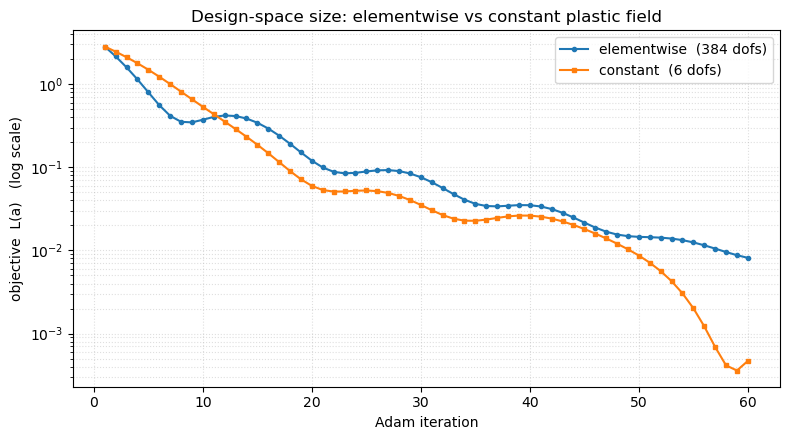

In [45]:
obj_ew = np.array([h[0] for h in history])
obj_const = np.array([h[0] for h in history_const])
steps = np.arange(1, num_outer_steps + 1)

plt.figure(figsize=(8, 4.5))
plt.semilogy(steps, obj_ew, color="tab:blue", marker="o", ms=3, lw=1.5,
             label=f"elementwise  ({energy.num_plastic_dofs} dofs)")
plt.semilogy(steps, obj_const, color="tab:orange", marker="s", ms=3, lw=1.5,
             label=f"constant  ({energy_const.num_plastic_dofs} dofs)")
plt.xlabel("Adam iteration")
plt.ylabel("objective  L(a)   (log scale)")
plt.title("Design-space size: elementwise vs constant plastic field")
plt.grid(True, which="both", ls=":", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


In [46]:
# Clean final evaluation at the best shared tensor.
equilibrium_layer_const.reset_warm_start()
optimized_vertices_const = equilibrium_layer_const(
    torch.as_tensor(best_plastic_const, dtype=torch.float64)
).detach().numpy().copy()
final_residual_const = optimized_vertices_const - target_vertices
print_error_stats("constant-field final shape error",
                  vertex_error_stats(final_residual_const))

optimized_surface_const = pgo.mesh.TriMeshData(optimized_vertices_const, surface.elements)
pgo.vis.plot_surface(
    [target_surface, optimized_surface_const],
    titles=["target", "constant-field equilibrium"],
    colors=["palegreen", "gold"],
    show_edges=True,
    window_size=(900, 420),
)


[2026-06-04 17:14:43.900] [info] [NewtonSolver.cpp:383] Newton solve time: 0.043866
constant-field final shape error: global=0.026755  per-vertex RMS=0.002703  mean=0.002132  max=0.005507


Widget(value='<iframe src="http://localhost:49856/index.html?ui=P_0x3466eb2f0_20&reconnect=auto" class="pyvist…

## 13. Read the single learned tensor & compare

With a constant field the whole design is **one** symmetric tensor $\mathbf S$.
Print it as a $3\times3$ matrix and the physics is legible: the off-diagonal
$S_{xy}$ carries the in-plane shear of the target
($\hat x\mathrel{+}=0.35\,y$) and $S_{yz}$ the out-of-plane shear
($\hat z\mathrel{+}=0.15\,y$); the diagonal stays near 1 (little stretch).


In [47]:
s = best_plastic_const
S = np.array([[s[0], s[1], s[2]],
              [s[1], s[3], s[4]],
              [s[2], s[4], s[5]]])
print("learned shared plastic tensor S =")
print(S)
print("plastic strain  S - I =")
print(S - np.eye(3))
print(f"dominant shear channels:  Sxy={s[1]:+.4f}  Syz={s[4]:+.4f}")

ew_err = float(np.linalg.norm(final_residual.ravel()))
const_err = float(np.linalg.norm(final_residual_const.ravel()))
print("\n--- elementwise vs constant ---")
print(f"{'field':<14}{'plastic dofs':>14}{'best objective':>18}{'global error':>16}")
print(f"{'elementwise':<14}{energy.num_plastic_dofs:>14}{best_value:>18.6f}{ew_err:>16.6f}")
print(f"{'constant':<14}{energy_const.num_plastic_dofs:>14}{best_value_const:>18.6f}{const_err:>16.6f}")


learned shared plastic tensor S =
[[ 0.9837  0.1734 -0.0031]
 [ 0.1734  1.0539  0.0747]
 [-0.0031  0.0747  0.9971]]
plastic strain  S - I =
[[-0.0163  0.1734 -0.0031]
 [ 0.1734  0.0539  0.0747]
 [-0.0031  0.0747 -0.0029]]
dominant shear channels:  Sxy=+0.1734  Syz=+0.0747

--- elementwise vs constant ---
field           plastic dofs    best objective    global error
elementwise              384          0.008144        0.126334
constant                   6          0.000360        0.026755


## 14. Recap, pitfalls, and extensions

### What we built

A complete **differentiable inverse-design** loop:

$$
\underbrace{\min_{\mathbf a}\;\tfrac12\lVert\mathbf x_{\text{surf}}(\mathbf a)-\hat{\mathbf x}\rVert^2+\tfrac{\mu_{\text{reg}}}{2}\lVert\mathbf a-\mathbf a_0\rVert^2}_{\text{outer: Adam}}
\quad\text{s.t.}\quad
\underbrace{\mathbf u^\star(\mathbf a)=\arg\min_{\mathbf u}E(\mathbf u,\mathbf a)}_{\text{inner: Newton}},
$$

with gradients supplied by the **adjoint method** through
`StaticEquilibriumLayer`. We ran it on the **same** target with two design
spaces — a per-element `ElementwiseField` (384 dofs) and a single shared
`ConstantField` tensor (6 dofs). For this spatially-uniform shear the constant
field matched *at least as well with $64\times$ fewer variables*: the right
**inductive bias beats raw capacity**.

### Pitfalls

| Pitfall | Why it matters |
|---|---|
| Plastic rest state is $(1,0,0,1,0,1)$, **not zeros** | $\mathbf S$ is a tensor whose identity is no-strain; the *strain* is $\mathbf S-\mathbf I$. Anchoring the regularizer / "delta" at zeros is wrong. |
| `enforce_spd=True` | Biases the adjoint Hessian → wrong gradient. Keep it `False` here. |
| `float32` or CUDA tensors | The layer requires CPU `float64`; it raises otherwise. |
| Trusting the last Adam iterate | Inner-solve tolerance makes $L$ slightly noisy; keep `best_plastic`. |
| Forgetting `reset_warm_start()` before the final solve | The final shape would depend on optimization history. |

### Verify the gradient yourself (finite differences)

For a random direction $\mathbf v$ and small $\varepsilon$, the directional
derivative should match the adjoint:
$\frac{L(\mathbf a+\varepsilon\mathbf v)-L(\mathbf a-\varepsilon\mathbf v)}{2\varepsilon}\approx \mathbf v^{\!\top}\nabla_{\mathbf a}L$.
This is the single best check when wiring a new differentiable physics layer.

### Extensions

- Swap the procedural cube for a real mesh (e.g. `veg/tet/bunny.veg`) and a
  scanned target surface — the API is identical.
- Match the **field granularity** to your target: `ConstantField` for
  homogeneous deformations, `ElementwiseField` for spatially varying ones.
  `dofs=3` (diagonal stretch) is a cheaper middle ground; shells use
  `ShellPlasticity` / `KoiterShell`.
- Replace Adam with `torch.optim.LBFGS`, which suits smooth deterministic
  objectives like this one.
- Add fabrication constraints (e.g. bound $\det\mathbf S$, or
  `projectParam`-style positivity) to the regularizer.
